# Medical Insurance Cost Prediction — Linear Regression
### Mini Project : EDA → Preprocessing → Model Training → Evaluation & Diagnostics

This notebook predicts individual medical insurance charges from `age`, `sex`, `bmi`, `children`, `smoker`, and `region`, comparing Linear Regression, Ridge, and Lasso, and diagnosing the final model's assumptions.

In [26]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats 

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,OneHotEncoder

## Module 1 — Dataset Selection & EDA

In [2]:
df = pd.read_csv("../data/insurance.csv")
print(df.shape)
df.head()

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print()
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)

Missing values per column:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows: 1
Shape after dropping duplicates: (1337, 7)


In [5]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.describe(include='object')

C:\Users\shreyas\AppData\Local\Temp\ipykernel_11328\87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,sex,smoker,region
count,1337,1337,1337
unique,2,2,4
top,male,no,southeast
freq,675,1063,364


In [7]:
print("Skewness ")
print("Age : ",round(df['age'].skew(),3))
print("Bmi : ",round(df['bmi'].skew(),3))
print("charges : ",round(df['charges'].skew(),3))

Skewness 
Age :  0.055
Bmi :  0.284
charges :  1.515


In [8]:
def iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lb = q1 - 1.5*iqr
    up = q3 + 1.5*iqr
    return series[(series<lb) | (series>up) ]

print("BMI outlayers ",len(iqr_outliers(df['bmi'])))
print("Charges outliers:", len(iqr_outliers(df["charges"])), f'({len(iqr_outliers(df["charges"]))/len(df)*100:.1f}% of data)')

BMI outlayers  9
Charges outliers: 139 (10.4% of data)


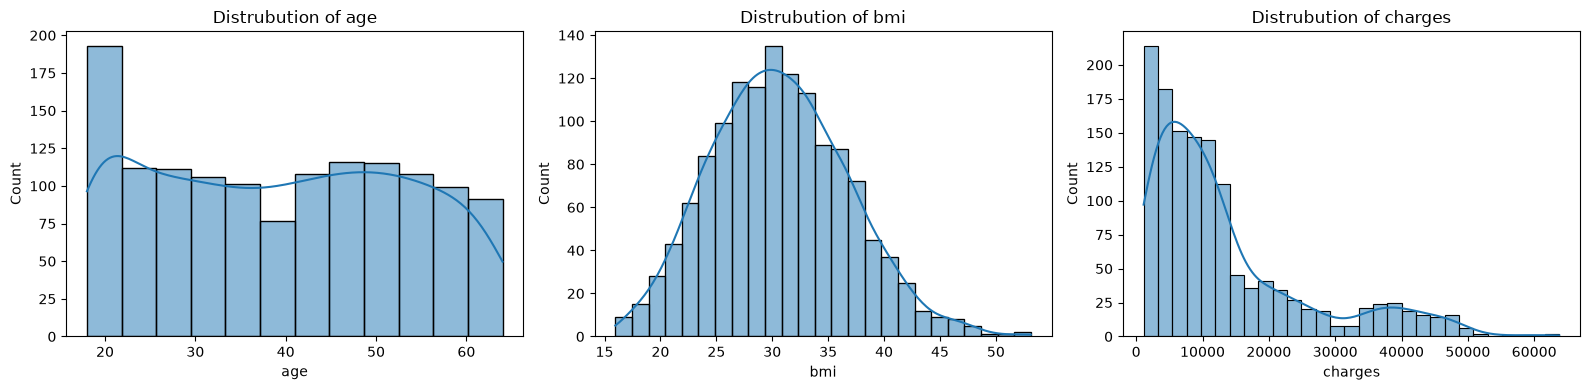

In [9]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

for ax,col in zip(axes,["age", "bmi", "charges"]) :
    sns.histplot(df[col],kde=True,ax=ax)
    ax.set_title(f"Distrubution of {col}")
plt.tight_layout()
plt.savefig("../images/univarient_numeric.png",dpi=300)
plt.show()

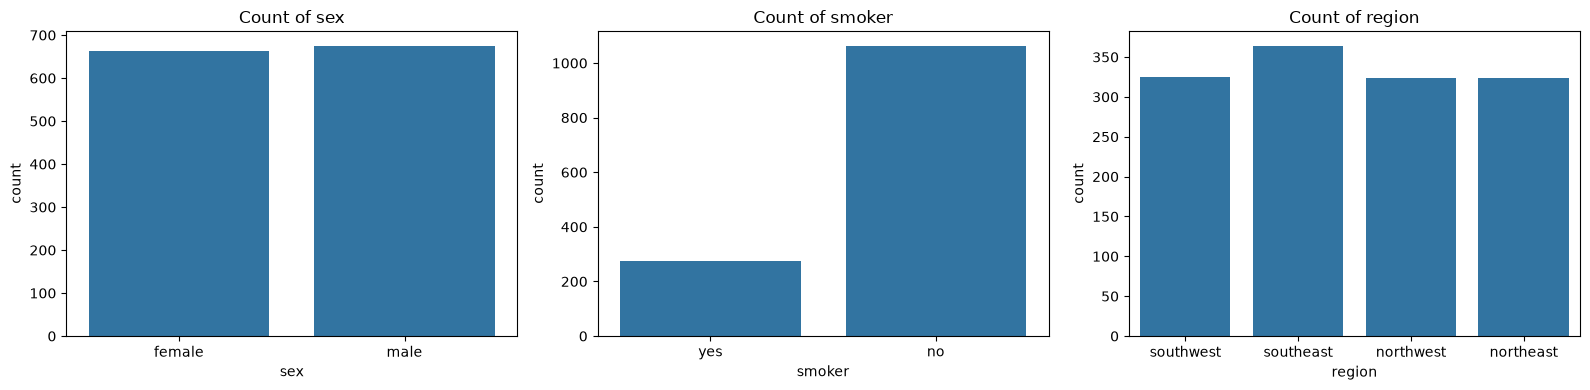

In [10]:
fig,axes = plt.subplots(1,3,figsize=(16,4))

for ax,col in zip(axes,["sex", "smoker", "region"]) :
    sns.countplot(data = df,x= col,ax=ax)
    ax.set_title(f"Count of {col}")
plt.tight_layout()
plt.savefig("../images/univarient_categoric.png",dpi=300)
plt.show()

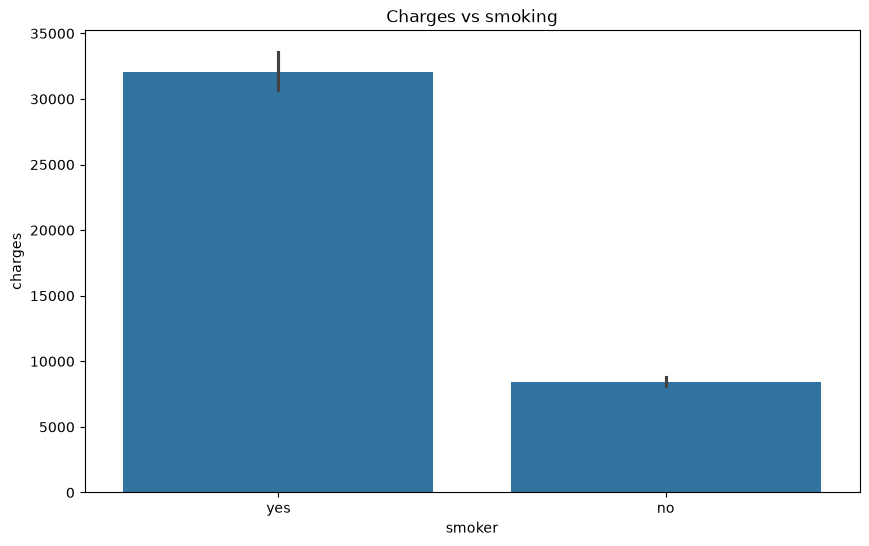

smoker
no      8440.66
yes    32050.23
Name: charges, dtype: float64


In [11]:
plt.figure(figsize=(10,6))
sns.barplot(x='smoker',y='charges',data=df)
plt.title("Charges vs smoking")
plt.savefig("../images/charges_by_Smoking.png", dpi=100)
plt.show()
print(df.groupby("smoker")["charges"].mean().round(2))

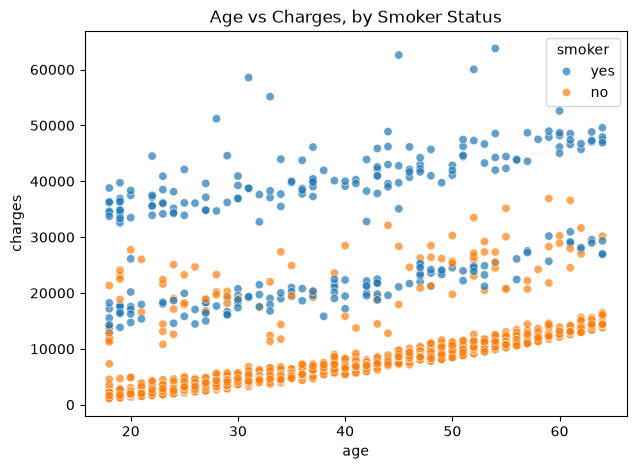

In [12]:
plt.figure(figsize=(7, 5))
sns.scatterplot(x="age",y="charges",hue="smoker",data=df,alpha=0.7)
plt.title("Age vs Charges, by Smoker Status")
plt.savefig("../images/age_vs_charges.png", dpi=100)
plt.show()

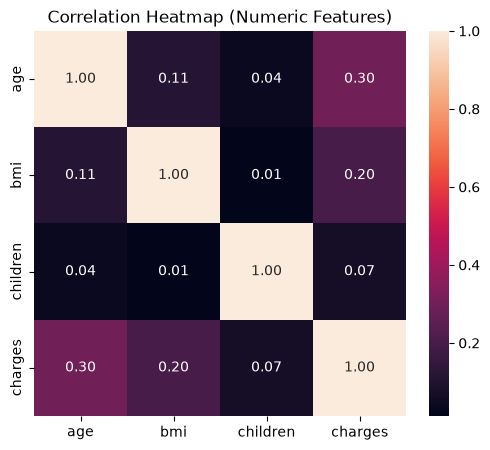

In [13]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[["age", "bmi", "children", "charges"]].corr(),annot=True,fmt=".2f")
plt.title("Correlation Heatmap (Numeric Features)")
plt.savefig("../images/correlation_heatmap.png", dpi=100)
plt.show()

**Module 1 Key Insights**
- No missing values; 1 duplicate row found and dropped (1338 → 1337 rows)
- `charges` is heavily right-skewed (skew ≈ 1.51) — a log-transform is worth testing in Module 2
- **Smokers pay ~4x more on average than non-smokers** — the single strongest driver of charges, and it's invisible in the numeric correlation heatmap since `smoker` is categorical
- 139 IQR-flagged "outliers" in `charges` are mostly genuine high-cost smoker cases — kept, not removed
- All three categorical columns (`sex`, `smoker`, `region`) need encoding before modeling

## Module 2 — Preprocessing Pipeline

In [14]:
X = df.drop('charges',axis=1)
y = df['charges']

In [17]:
x_train, x_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print("train data Shape : ",x_train.shape)
print("test data Shape : ",x_test.shape)

train data Shape :  (1069, 6)
test data Shape :  (268, 6)


In [32]:
numeric_features = ['age','bmi','children']
categorical_features = ['sex','smoker','region']

preprocessing = ColumnTransformer([('Num',StandardScaler(),numeric_features),
                                   ('category',OneHotEncoder(drop='first',handle_unknown='ignore'),categorical_features)])

x_train_transform = preprocessing.fit_transform(x_train)
print("shape of x_train_transform ",x_train_transform.shape)
print("Features :",preprocessing.get_feature_names_out())


shape of x_train_transform  (1069, 8)
Features : ['Num__age' 'Num__bmi' 'Num__children' 'category__sex_male'
 'category__smoker_yes' 'category__region_northwest'
 'category__region_southeast' 'category__region_southwest']


In [ ]:
print("Skew of charges (raw):        ", round(y_train.skew(), 3))
print("Skew of log1p(charges):        ", round(np.log1p(y_train).skew(), 3))
print("-> log1p almost completely fixes the target's skew")

Skew of charges (raw):         1.51
Skew of log1p(charges):         -0.102
-> log1p almost completely fixes the target's skew


**Module 2 Summary**
- Dropped duplicate, split before fitting anything (leakage prevention)
- `ColumnTransformer`: `StandardScaler` on numeric features, `OneHotEncoder(drop="first", handle_unknown="ignore")` on categorical — verified output: 8 columns
- `log1p` transform brings `charges`' skew from 1.51 down to essentially 0 — tested in Module 3 via `TransformedTargetRegressor`

## Module 3 — Model Training (Linear vs. Ridge vs. Lasso)